In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import copy,os,random

def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    
    if X.shape[1]<pc:
        pc = X.shape[1]#PLSR的主成分数不能大于X的特征数量。
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean

In [3]:
#导入玉米数据：
from scipy.io import loadmat
path = r'C:\Users\Think\Documents\MATLAB\EPO and GLSW\carspls\Corn_data'
m5spec = loadmat(os.path.join(path,'m5spec.mat'))
w = loadmat(os.path.join(path,'wavelength.mat'))
prop = loadmat(os.path.join(path,'prop4.mat'))
X = m5spec['m5spec']
y = prop['prop'][:,0]

print(X.shape,y.shape)

(80, 700) (80,)


In [4]:
#深入CARS_Cloud（）函数：
num = 50
f = 8
cv = 10
Mx = X.shape[0]#样品数量
Nx = X.shape[1]#样品波长点数量（特征数量）
f = min([Mx,Nx,f])#f不超过样品数，也不超过样品特征数
Mx,Nx,f

(80, 700, 8)

In [5]:
ratio = 0.8#建模校正集样品占比
r0=1#初始波长点保留率
r1=2/Nx
    
Vsel = np.arange(0,Nx)#初始筛选波长点位置数据，
#第一次循环取所有波长点数据，Vsel每次循环会改变数值和大小。这是一个需要重点关注的参数。
Q = int(np.floor(Mx*ratio));#建模校正集样品数量
W = np.zeros((Nx,num))#用于保存每次循环的PLSR模型的参数（每列），这是一个非常重要的参数
Ratio = []#空列表，用于保存每次循环波长点保留率。
    
WaveNum =[]#列表，用于保存下面各次循环保存的波长点数量
    
## 定义文章中的指数下降函数两个参数：
#b就是文章中的k参数（公式6）；a还是a（文章公式5）
b = np.log(r0/r1)/(num-1)
a = r0*np.exp(b)
x = copy.deepcopy(X)

In [6]:
#主循环：
for iter in np.arange(1,num+1):#循环50次（默认）
    Ratio.append(a*np.exp(-1*b*iter))#u*np.exp(-1*k*i):各次循环的波长点的保留率,同书P81推导
    K = int(np.round(Ratio[iter-1]*Nx))#K：每次循环保留的波长点的数量，每次循环都会变
    WaveNum = np.hstack((WaveNum, K)).astype(int)

In [7]:
Ratio

[1.0,
 0.8873199457760146,
 0.7873366861719493,
 0.6986195456815611,
 0.6198990573922267,
 0.5500487979918731,
 0.4880692696083109,
 0.4330735978437854,
 0.38427484135577117,
 0.34097473139488943,
 0.30255368017230444,
 0.2684619150848228,
 0.23821161193599,
 0.2113699145862597,
 0.18755274114936077,
 0.16641928810679368,
 0.14766715369900307,
 0.1310280108130978,
 0.11626376744981701,
 0.10316315982928677,
 0.0915387293858051,
 0.08122414039501784,
 0.07207179985101062,
 0.06395074553577851,
 0.056744772061142694,
 0.050350768068365435,
 0.0446772407922027,
 0.039643006877159256,
 0.03517603071263912,
 0.031212393664554364,
 0.027695379453971998,
 0.024574662595344576,
 0.021805588281565005,
 0.019348533411612356,
 0.01716833961763728,
 0.015233810178586112,
 0.013517263621625126,
 0.011994137623780501,
 0.01064263754596297,
 0.009443424570197636,
 0.008379338977567657,
 0.0074351546072141785,
 0.00659736098290957,
 0.005853969989620113,
 0.005194344333764134,
 0.00460904533257754,
 0

In [8]:
WaveNum

array([700, 621, 551, 489, 434, 385, 342, 303, 269, 239, 212, 188, 167,
       148, 131, 116, 103,  92,  81,  72,  64,  57,  50,  45,  40,  35,
        31,  28,  25,  22,  19,  17,  15,  14,  12,  11,   9,   8,   7,
         7,   6,   5,   5,   4,   4,   3,   3,   3,   2,   2])

In [9]:
#主循环第一次循环：
iter = 1
cal_index = np.random.choice    \
        (np.arange(Mx), size=int(Q), replace=False)#从0~Mx-1中随机取Q个数，
#且不重复
xcal = x[np.ix_(list(cal_index),list(Vsel.astype(int)))]#按cal_index随机取样品数的光谱，
#按Vsel取波长点数
ycal = y[cal_index]
        
MM = xcal.shape[0]
NN = xcal.shape[1]
f = min([MM,NN,f])
pls = PLSRegression(n_components=f)#创建PLSR模型，主成分数为f,默认为8
pls.fit(xcal,ycal)
coef = pls.coef_#获取模型参数（1，n）反映每个波长点对y变量的相关贡献程度
coef = coef.T#（n,1），注意n的大小每次循环会改变。
w = np.zeros((Nx,1))#创建一个Nx*1的列向量
w[Vsel.astype(int)] = coef#w也是一个需要重点关注的参数。
W[:,iter-1] = w.squeeze() #将每次循环PLSR模型参数保存到W的每一列中。小w用来对模型参数进行排序
w = np.abs(w)#对每次循环建立的PLSR模型的参数取绝对值，w全部变成正数了。
indexw = np.argsort(-w.squeeze())##按模型参数绝对值大小，从大到小排序，indexw返回原数据在coef的
#位置序号
#coeff = coef[indexw];#coeff是按绝对值从大到小排序后的向量。
KK = int(np.round(a*np.exp(-1*b*(iter+1))*Nx))
w[indexw[KK:]]=0#只保留"波长点保留数"大小的模型参数

w.shape,w #绝对值较小的后79个数值直接归零了。

((700, 1),
 array([[0.02193604],
        [0.01957831],
        [0.01963714],
        [0.01778116],
        [0.0173495 ],
        [0.01400497],
        [0.01513257],
        [0.01396545],
        [0.01139864],
        [0.00931373],
        [0.00558256],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00761875],
        [0.01096375],
        [0.01370191],
        [0.0171012 ],
        [0.01972503],
        [0.02241891],
        [0.02408541],
        [0.02412249],
        [0.02397228],
        [0.02400018],
        [0.02517146],
        [0.02422979],
        [0.02388955],
        [0.02428689],
        [0.02338711],
        [0.02306044],
        [0.02136575],
        [0.01947515],
        [0.01812981],
        [0.0164527 ],
        [0.01396858],
        [0.01144507],
        [0.00974433],
        [0.00713123],
        [0.00542358],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00637485],

In [10]:
#进入重点函数weightsampling_in(w):
w = w/np.sum(w)
w.shape,w #下面根据w大小决定该波长点位置保留概率。
#w[i] 越大，保留概率越大

((700, 1),
 array([[0.00136464],
        [0.00121797],
        [0.00122163],
        [0.00110617],
        [0.00107931],
        [0.00087125],
        [0.0009414 ],
        [0.00086879],
        [0.00070911],
        [0.00057941],
        [0.00034729],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00047396],
        [0.00068205],
        [0.0008524 ],
        [0.00106386],
        [0.00122709],
        [0.00139468],
        [0.00149835],
        [0.00150066],
        [0.00149131],
        [0.00149305],
        [0.00156592],
        [0.00150733],
        [0.00148617],
        [0.00151089],
        [0.00145491],
        [0.00143459],
        [0.00132916],
        [0.00121155],
        [0.00112785],
        [0.00102352],
        [0.00086898],
        [0.000712  ],
        [0.00060619],
        [0.00044363],
        [0.0003374 ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00039658],

In [11]:
"""
在Python中，根据概率从一个范围中随机选取数字，可以使用random模块中的choices函数，
并结合weights参数来实现。choices函数可以让你指定每个元素被选中的概率。
"""

'\n在Python中，根据概率从一个范围中随机选取数字，可以使用random模块中的choices函数，\n并结合weights参数来实现。choices函数可以让你指定每个元素被选中的概率。\n'

In [70]:
import random
 
# 数字范围
numbers = range(1, 11)
 
# 每个数字被选中的概率（例如：1有20%的概率被选中，其他数字各10%）
weights = [0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
 
# 使用weights参数选择数字
chosen_number = random.choices(numbers, weights=weights,k = 10)
 
print(chosen_number)

[4, 2, 9, 4, 7, 3, 3, 9, 6, 10]


In [17]:
chosen_number

[4]

In [18]:
numbers

range(1, 11)

In [23]:
chose_number = random.choices(range(0,Nx),weights = w,k=Nx)
len(chose_number),chose_number

(700,
 [269,
  671,
  164,
  202,
  335,
  254,
  148,
  497,
  404,
  610,
  541,
  174,
  591,
  216,
  52,
  449,
  677,
  462,
  240,
  157,
  499,
  97,
  420,
  237,
  121,
  204,
  174,
  206,
  240,
  119,
  25,
  422,
  454,
  454,
  524,
  695,
  409,
  252,
  359,
  140,
  327,
  147,
  387,
  375,
  263,
  418,
  468,
  523,
  692,
  493,
  487,
  160,
  671,
  616,
  401,
  443,
  258,
  415,
  122,
  95,
  421,
  85,
  693,
  130,
  491,
  151,
  534,
  295,
  581,
  500,
  157,
  230,
  414,
  93,
  494,
  546,
  136,
  423,
  693,
  242,
  447,
  497,
  404,
  567,
  468,
  664,
  435,
  178,
  129,
  562,
  668,
  505,
  487,
  409,
  270,
  280,
  143,
  297,
  414,
  666,
  402,
  25,
  432,
  405,
  424,
  481,
  390,
  435,
  6,
  568,
  137,
  565,
  514,
  154,
  439,
  460,
  440,
  143,
  239,
  224,
  263,
  393,
  236,
  185,
  580,
  410,
  410,
  269,
  414,
  6,
  171,
  302,
  404,
  134,
  536,
  390,
  414,
  599,
  408,
  161,
  142,
  511,
  518,
  14

In [24]:
w.shape,w

((700, 1),
 array([[0.00136464],
        [0.00121797],
        [0.00122163],
        [0.00110617],
        [0.00107931],
        [0.00087125],
        [0.0009414 ],
        [0.00086879],
        [0.00070911],
        [0.00057941],
        [0.00034729],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00047396],
        [0.00068205],
        [0.0008524 ],
        [0.00106386],
        [0.00122709],
        [0.00139468],
        [0.00149835],
        [0.00150066],
        [0.00149131],
        [0.00149305],
        [0.00156592],
        [0.00150733],
        [0.00148617],
        [0.00151089],
        [0.00145491],
        [0.00143459],
        [0.00132916],
        [0.00121155],
        [0.00112785],
        [0.00102352],
        [0.00086898],
        [0.000712  ],
        [0.00060619],
        [0.00044363],
        [0.0003374 ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00039658],

In [26]:
np.sort(chose_number)#从小到大排序

array([  0,   0,   0,   1,   1,   3,   5,   6,   6,  10,  16,  19,  20,
        20,  21,  22,  25,  25,  25,  26,  26,  26,  26,  26,  28,  29,
        30,  31,  32,  32,  34,  35,  35,  52,  56,  58,  60,  61,  74,
        77,  82,  82,  82,  84,  85,  86,  87,  88,  89,  93,  95,  97,
        97,  97,  98,  99, 117, 117, 119, 119, 121, 121, 122, 122, 123,
       123, 128, 129, 129, 129, 130, 131, 133, 133, 134, 135, 136, 137,
       139, 139, 139, 140, 140, 142, 142, 143, 143, 143, 143, 143, 144,
       145, 145, 145, 147, 148, 148, 150, 150, 151, 151, 151, 151, 151,
       151, 151, 152, 153, 153, 153, 153, 153, 154, 154, 155, 155, 155,
       155, 156, 156, 156, 156, 157, 157, 157, 157, 157, 158, 158, 158,
       158, 158, 159, 159, 159, 160, 160, 160, 161, 161, 161, 161, 162,
       163, 163, 163, 163, 164, 164, 164, 165, 165, 165, 165, 166, 166,
       167, 168, 168, 168, 168, 168, 168, 168, 168, 169, 171, 171, 172,
       174, 174, 174, 175, 177, 178, 185, 185, 186, 200, 202, 20

In [27]:
b = np.unique(np.sort(chose_number))
b.shape,b

((358,),
 array([  0,   1,   3,   5,   6,  10,  16,  19,  20,  21,  22,  25,  26,
         28,  29,  30,  31,  32,  34,  35,  52,  56,  58,  60,  61,  74,
         77,  82,  84,  85,  86,  87,  88,  89,  93,  95,  97,  98,  99,
        117, 119, 121, 122, 123, 128, 129, 130, 131, 133, 134, 135, 136,
        137, 139, 140, 142, 143, 144, 145, 147, 148, 150, 151, 152, 153,
        154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166,
        167, 168, 169, 171, 172, 174, 175, 177, 178, 185, 186, 200, 202,
        203, 204, 205, 206, 207, 210, 212, 214, 216, 217, 218, 219, 221,
        224, 227, 228, 229, 230, 231, 232, 233, 236, 237, 239, 240, 241,
        242, 243, 244, 245, 246, 247, 250, 251, 252, 253, 254, 255, 256,
        257, 258, 259, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270,
        271, 272, 273, 274, 275, 276, 277, 280, 282, 283, 284, 291, 295,
        296, 297, 300, 302, 303, 304, 320, 325, 327, 328, 329, 330, 335,
        359, 360, 364, 369, 374, 375, 377,

In [28]:
#定义自适应重加权采样函数（Adaptive reweighted sampling）
def weightsampling_in(w):
    #%输入参数是根据每次循环波长点保留率去除了（归零）绝对值较小的模型参数后
    #%的遗留模型参数。注意：w是取了绝对值后的模型参数向量。
    #%Bootstrap sampling
    w = w/np.sum(w) #同文献公式（3），计算w向量每一个元素所占权重
    N1 = w.shape[0]
    chosen_number = random.choices(range(0,N1),weights = w,k=N1)#符合梁文章的Fig.2
    #权重越大，波长点位置被选择的概率越大
    a = np.sort(chosen_number)#从小到大排序
    Vsel = np.unique(a)
    return Vsel #返回的Vsel就是ARS选择的波长点位置数据

In [29]:
#深入CARSPLS_wzj_2.py
num = 50
f = 8
cv = 10
Mx = X.shape[0]#样品数量
Nx = X.shape[1]#样品波长点数量（特征数量）
f = min([Mx,Nx,f])#f不超过样品数，也不超过样品特征数
    
ratio = 0.8#建模校正集样品占比
r0=1#初始波长点保留率
r1=2/Nx
    
Vsel = np.arange(0,Nx)#初始筛选波长点位置数据，
#第一次循环取所有波长点数据，Vsel每次循环会改变数值和大小。这是一个需要重点关注的参数。
Q = int(np.floor(Mx*ratio));#建模校正集样品数量
W = np.zeros((Nx,num))#用于保存每次循环的PLSR模型的参数（每列），这是一个非常重要的参数
Ratio = []#空列表，用于保存每次循环波长点保留率。
    
WaveNum =[]#列表，用于保存下面各次循环保存的波长点数量
    
## 定义文章中的指数下降函数两个参数：
#b就是文章中的k参数（公式6）；a还是a（文章公式5）
b = np.log(r0/r1)/(num-1)
a = r0*np.exp(b)
x = copy.deepcopy(X)

In [30]:
#主循环第一次循环：
for iter in np.arange(1,num+1):#循环50次（默认）
    Ratio.append(a*np.exp(-1*b*iter))#u*np.exp(-1*k*i):各次循环的波长点的保留率,同书P81推导
    K = int(np.round(Ratio[iter-1]*Nx))#K：每次循环保留的波长点的数量，每次循环都会变
    WaveNum = np.hstack((WaveNum, K)).astype(int)#WaveNum转为np数组，用于保存每次循环保留的波长点      #的数量
Ratio

[1.0,
 0.8873199457760146,
 0.7873366861719493,
 0.6986195456815611,
 0.6198990573922267,
 0.5500487979918731,
 0.4880692696083109,
 0.4330735978437854,
 0.38427484135577117,
 0.34097473139488943,
 0.30255368017230444,
 0.2684619150848228,
 0.23821161193599,
 0.2113699145862597,
 0.18755274114936077,
 0.16641928810679368,
 0.14766715369900307,
 0.1310280108130978,
 0.11626376744981701,
 0.10316315982928677,
 0.0915387293858051,
 0.08122414039501784,
 0.07207179985101062,
 0.06395074553577851,
 0.056744772061142694,
 0.050350768068365435,
 0.0446772407922027,
 0.039643006877159256,
 0.03517603071263912,
 0.031212393664554364,
 0.027695379453971998,
 0.024574662595344576,
 0.021805588281565005,
 0.019348533411612356,
 0.01716833961763728,
 0.015233810178586112,
 0.013517263621625126,
 0.011994137623780501,
 0.01064263754596297,
 0.009443424570197636,
 0.008379338977567657,
 0.0074351546072141785,
 0.00659736098290957,
 0.005853969989620113,
 0.005194344333764134,
 0.00460904533257754,
 0

In [31]:
K

2

In [32]:
WaveNum

array([700, 621, 551, 489, 434, 385, 342, 303, 269, 239, 212, 188, 167,
       148, 131, 116, 103,  92,  81,  72,  64,  57,  50,  45,  40,  35,
        31,  28,  25,  22,  19,  17,  15,  14,  12,  11,   9,   8,   7,
         7,   6,   5,   5,   4,   4,   3,   3,   3,   2,   2])

In [34]:
Vsel.shape,Vsel

((700,),
 array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175,

In [33]:
iter = 1
cal_index = np.random.choice    \
        (np.arange(Mx), size=int(Q), replace=False)#从0~Mx-1中随机取Q个数，
#且不重复
xcal = x[np.ix_(list(cal_index),list(Vsel.astype(int)))]#按cal_index随机取样品数的光谱，
#按Vsel取波长点数
ycal = y[cal_index]
xcal.shape,ycal.shape

((64, 700), (64,))

In [35]:
MM = xcal.shape[0]
NN = xcal.shape[1]
f = min([MM,NN,f])
pls = PLSRegression(n_components=f)#创建PLSR模型，主成分数为f,默认为8
pls.fit(xcal,ycal)
coef = pls.coef_#获取模型参数（1，n）反映每个波长点对y变量的相关贡献程度
coef = coef.T#（n,1），注意n的大小每次循环会改变。
w = np.zeros((Nx,1))#创建一个Nx*1的列向量
w[Vsel.astype(int)] = coef#w也是一个需要重点关注的参数。
W[:,iter-1] = w.squeeze() #将每次循环PLSR模型参数保存到W的每一列中。小w用来对模型参数进行排序
w = np.abs(w)#对每次循环建立的PLSR模型的参数取绝对值，w全部变成正数了。
indexw = np.argsort(-w.squeeze())##按模型参数绝对值大小，从大到小排序，indexw返回原数据在coef的
#位置序号
#coeff = coef[indexw];#coeff是按绝对值从大到小排序后的向量。
KK = int(np.round(a*np.exp(-1*b*(iter+1))*Nx))
w[indexw[KK:]]=0#只保留"波长点保留数"大小的模型参数

w.shape,w

((700, 1),
 array([[0.01220382],
        [0.01300698],
        [0.01345408],
        [0.01023914],
        [0.01063918],
        [0.0109797 ],
        [0.01098316],
        [0.00893243],
        [0.00672631],
        [0.00671868],
        [0.00535969],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00491354],
        [0.00670947],
        [0.00858998],
        [0.0112293 ],
        [0.01346112],
        [0.0160336 ],
        [0.01713726],
        [0.01815949],
        [0.01918214],
        [0.01974586],
        [0.02114326],
        [0.0205395 ],
        [0.02101009],
        [0.02163187],
        [0.02102286],
        [0.02112174],
        [0.02005971],
        [0.01907682],
        [0.01801626],
        [0.01563411],
        [0.01378716],
        [0.01194777],
        [0.00986095],
        [0.00704182],
        [0.00500194],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.00483411],
        [0.00661916],

In [36]:
Vsel=weightsampling_in(w);#Adaptive reweighted sampling的程序实现函数%+++ Reweighted Sampling from the pool of retained variables.                 
#Vsel= np.unique(Vsel)#用于查找并移除数组中的重复元素，并返回经过排序（从小到大）的唯一元素列表。数据量会下降            
print('The %dth variable sampling finished.\n'%iter) 
Vsel.shape,Vsel

The 1th variable sampling finished.



((357,),
 array([  2,   5,   7,  19,  21,  22,  24,  25,  26,  27,  30,  31,  34,
         36,  38,  43,  48,  50,  55,  57,  73,  74,  76,  78,  82,  83,
         84,  85,  86,  89,  90,  96,  97, 100, 102, 104, 105, 106, 117,
        120, 121, 124, 126, 127, 128, 129, 131, 132, 135, 138, 140, 142,
        143, 146, 147, 148, 151, 152, 154, 155, 156, 157, 158, 160, 161,
        162, 163, 164, 165, 166, 167, 168, 169, 170, 172, 174, 175, 176,
        177, 178, 179, 182, 186, 198, 200, 203, 204, 206, 208, 209, 210,
        212, 213, 215, 216, 217, 220, 221, 224, 227, 229, 230, 232, 233,
        234, 236, 238, 240, 242, 243, 244, 245, 246, 248, 249, 250, 251,
        252, 254, 255, 256, 257, 258, 259, 260, 261, 262, 264, 265, 266,
        267, 268, 269, 270, 271, 272, 274, 275, 276, 277, 278, 279, 280,
        281, 282, 283, 286, 288, 289, 292, 296, 298, 299, 301, 302, 304,
        321, 325, 327, 328, 330, 339, 340, 345, 346, 365, 372, 373, 374,
        375, 376, 381, 382, 383, 384, 385,

In [37]:
#主循环第二次循环：
xcal = x[np.ix_(list(cal_index),list(Vsel.astype(int)))]#按cal_index随机取样品数的光谱，
#按Vsel取波长点数
ycal = y[cal_index]
xcal.shape,ycal.shape

((64, 357), (64,))

In [39]:
MM = xcal.shape[0]
NN = xcal.shape[1]
f = min([MM,NN,f])
pls = PLSRegression(n_components=f)#创建PLSR模型，主成分数为f,默认为8
pls.fit(xcal,ycal)
coef = pls.coef_#获取模型参数（1，n）反映每个波长点对y变量的相关贡献程度
coef = coef.T#（n,1），注意n的大小每次循环会改变。
coef.shape,coef

((357, 1),
 array([[-0.02884027],
        [-0.02538263],
        [-0.02251068],
        [ 0.01619012],
        [ 0.01928599],
        [ 0.02102901],
        [ 0.02327611],
        [ 0.02273382],
        [ 0.02347869],
        [ 0.02347658],
        [ 0.02167862],
        [ 0.02080479],
        [ 0.01450706],
        [ 0.01010574],
        [ 0.00391309],
        [-0.01055722],
        [-0.01961928],
        [-0.02048288],
        [-0.0180597 ],
        [-0.0145729 ],
        [-0.00574648],
        [-0.00696375],
        [-0.00973698],
        [-0.01192435],
        [-0.01444959],
        [-0.0156736 ],
        [-0.01565127],
        [-0.01594338],
        [-0.01576663],
        [-0.01691513],
        [-0.01609784],
        [-0.01716646],
        [-0.01721586],
        [-0.0154891 ],
        [-0.01484936],
        [-0.01297501],
        [-0.01202091],
        [-0.01138881],
        [ 0.00436874],
        [ 0.00944004],
        [ 0.01225726],
        [ 0.01511396],
        [ 0.01805936],


In [40]:
w = np.zeros((Nx,1))#创建一个Nx*1的列向量
w[Vsel.astype(int)] = coef#w也是一个需要重点关注的参数。
W[:,iter-1] = w.squeeze() #将每次循环PLSR模型参数保存到W的每一列中。小w用来对模型参数进行排序
w = np.abs(w)#对每次循环建立的PLSR模型的参数取绝对值，w全部变成正数了。
indexw = np.argsort(-w.squeeze())##按模型参数绝对值大小，从大到小排序，indexw返回原数据在coef的
#位置序号
#coeff = coef[indexw];#coeff是按绝对值从大到小排序后的向量。
KK = int(np.round(a*np.exp(-1*b*(iter+1))*Nx))
w[indexw[KK:]]=0
w.shape,w

((700, 1),
 array([[0.        ],
        [0.        ],
        [0.02884027],
        [0.        ],
        [0.        ],
        [0.02538263],
        [0.        ],
        [0.02251068],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.01619012],
        [0.        ],
        [0.01928599],
        [0.02102901],
        [0.        ],
        [0.02327611],
        [0.02273382],
        [0.02347869],
        [0.02347658],
        [0.        ],
        [0.        ],
        [0.02167862],
        [0.02080479],
        [0.        ],
        [0.        ],
        [0.01450706],
        [0.        ],
        [0.01010574],
        [0.        ],
        [0.00391309],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.01055722],
        [0.        ],

In [41]:
Vsel=weightsampling_in(w)
Vsel.shape,Vsel

((261,),
 array([  2,   5,  19,  21,  24,  25,  27,  55,  73,  76,  78,  83,  84,
         86,  96,  97, 100, 102, 104, 127, 128, 131, 135, 140, 142, 143,
        146, 147, 148, 152, 155, 156, 157, 158, 161, 162, 163, 164, 165,
        166, 167, 168, 169, 170, 175, 176, 177, 204, 210, 215, 216, 217,
        220, 221, 224, 227, 229, 230, 233, 234, 236, 238, 240, 242, 244,
        245, 246, 248, 249, 250, 251, 252, 254, 255, 256, 257, 258, 259,
        260, 261, 262, 264, 265, 266, 267, 268, 269, 270, 271, 272, 274,
        275, 276, 277, 278, 279, 281, 282, 283, 286, 298, 299, 304, 321,
        325, 327, 339, 346, 372, 373, 374, 375, 376, 382, 383, 384, 385,
        386, 387, 389, 390, 391, 392, 393, 394, 395, 396, 397, 399, 400,
        401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413,
        414, 415, 417, 418, 421, 422, 423, 424, 426, 428, 429, 432, 434,
        435, 437, 439, 440, 441, 442, 443, 444, 446, 447, 448, 449, 450,
        452, 453, 458, 459, 462, 466, 476,

In [44]:
Mx = X.shape[0]#样品数量
Nx = X.shape[1]#样品波长点数量（特征数量）
f = min([Mx,Nx,f])#f不超过样品数，也不超过样品特征数
    
ratio = 0.8#建模校正集样品占比
r0=1#初始波长点保留率
r1=2/Nx
    
Vsel = np.arange(0,Nx)#初始筛选波长点位置数据，
#第一次循环取所有波长点数据，Vsel每次循环会改变数值和大小。这是一个需要重点关注的参数。
Q = int(np.floor(Mx*ratio));#建模校正集样品数量
W = np.zeros((Nx,num))#用于保存每次循环的PLSR模型的参数（每列），这是一个非常重要的参数
Ratio = []#空列表，用于保存每次循环波长点保留率。
    
WaveNum =[]#列表，用于保存下面各次循环保存的波长点数量
    
## 定义文章中的指数下降函数两个参数：
#b就是文章中的k参数（公式6）；a还是a（文章公式5）
b = np.log(r0/r1)/(num-1)
a = r0*np.exp(b)
x = copy.deepcopy(X)

#主循环全部运行一遍：
for iter in np.arange(1,num+1):#循环50次（默认）
    Ratio.append(a*np.exp(-1*b*iter))#u*np.exp(-1*k*i):各次循环的波长点的保留率,同书P81推导
    K = int(np.round(Ratio[iter-1]*Nx))#K：每次循环保留的波长点的数量，每次循环都会变
    WaveNum = np.hstack((WaveNum, K)).astype(int)#WaveNum转为np数组，用于保存每次循环保留的波长点      #的数量
    cal_index = np.random.choice    \
        (np.arange(Mx), size=int(Q), replace=False)#从0~Mx-1中随机取Q个数，
    #且不重复
    xcal = x[np.ix_(list(cal_index),list(Vsel.astype(int)))]#按cal_index随机取样品数的光谱，
    #按Vsel取波长点数
    ycal = y[cal_index]
        
    MM = xcal.shape[0]
    NN = xcal.shape[1]
    f = min([MM,NN,f])
    pls = PLSRegression(n_components=f)#创建PLSR模型，主成分数为f,默认为8
    pls.fit(xcal,ycal)
    coef = pls.coef_#获取模型参数（1，n）反映每个波长点对y变量的相关贡献程度
    coef = coef.T#（n,1），注意n的大小每次循环会改变。
    w = np.zeros((Nx,1))#创建一个Nx*1的列向量
    w[Vsel.astype(int)] = coef#w也是一个需要重点关注的参数。
    W[:,iter-1] = w.squeeze() #将每次循环PLSR模型参数保存到W的每一列中。小w用来对模型参数进行排序
    w = np.abs(w)#对每次循环建立的PLSR模型的参数取绝对值，w全部变成正数了。
    indexw = np.argsort(-w.squeeze())##按模型参数绝对值大小，从大到小排序，indexw返回原数据在coef的
    #位置序号
    #coeff = coef[indexw];#coeff是按绝对值从大到小排序后的向量。
    KK = int(np.round(a*np.exp(-1*b*(iter+1))*Nx))
    w[indexw[KK:]]=0#只保留"波长点保留数"大小的模型参数
    #绝对值较小的模型参数归零，归零的比例为ratio
    # %+++ Eliminate some variables with small coefficients. 
    Vsel=weightsampling_in(w)#Adaptive reweighted sampling的程序实现函数%+++ Reweighted Sampling from the pool of retained variables.                 
    #Vsel= np.unique(Vsel)#用于查找并移除数组中的重复元素，并返回经过排序（从小到大）的唯一元素列表。数据量会下降            
    print('The %dth variable sampling finished.\n'%iter)    #%+++ Screen output.

The 1th variable sampling finished.

The 2th variable sampling finished.

The 3th variable sampling finished.

The 4th variable sampling finished.

The 5th variable sampling finished.

The 6th variable sampling finished.

The 7th variable sampling finished.

The 8th variable sampling finished.

The 9th variable sampling finished.

The 10th variable sampling finished.

The 11th variable sampling finished.

The 12th variable sampling finished.

The 13th variable sampling finished.

The 14th variable sampling finished.

The 15th variable sampling finished.

The 16th variable sampling finished.

The 17th variable sampling finished.

The 18th variable sampling finished.

The 19th variable sampling finished.

The 20th variable sampling finished.

The 21th variable sampling finished.

The 22th variable sampling finished.

The 23th variable sampling finished.

The 24th variable sampling finished.

The 25th variable sampling finished.

The 26th variable sampling finished.

The 27th variable sam

In [45]:
W.shape,W

((700, 50),
 array([[ 0.00124209,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.00128076,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.00128985,  0.00067682,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.00298479, -0.00341685, -0.00471563, ...,  0.        ,
          0.        ,  0.        ],
        [-0.00296861, -0.00339493, -0.00469829, ...,  0.        ,
          0.        ,  0.        ],
        [-0.00297012, -0.00337501, -0.00469227, ...,  0.        ,
          0.        ,  0.        ]]))

In [46]:
W[:,-1]

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [47]:
#直接验证CARSPLS_wzj_2.py
import CARSPLS_wzj_2

The 1th variable sampling finished.

The 2th variable sampling finished.

The 3th variable sampling finished.

The 4th variable sampling finished.

The 5th variable sampling finished.

The 6th variable sampling finished.

The 7th variable sampling finished.

The 8th variable sampling finished.

The 9th variable sampling finished.

The 10th variable sampling finished.

The 11th variable sampling finished.

The 12th variable sampling finished.

The 13th variable sampling finished.

The 14th variable sampling finished.

The 15th variable sampling finished.

The 16th variable sampling finished.

The 17th variable sampling finished.

The 18th variable sampling finished.

The 19th variable sampling finished.

The 20th variable sampling finished.

The 21th variable sampling finished.

The 22th variable sampling finished.

The 23th variable sampling finished.

The 24th variable sampling finished.

The 25th variable sampling finished.

The 26th variable sampling finished.

The 27th variable sam

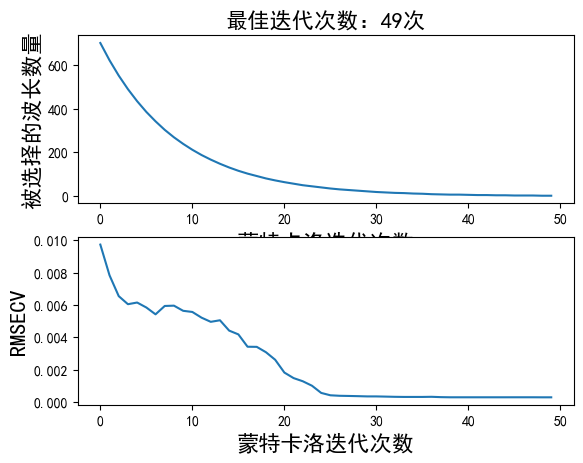

In [48]:
ow2 = CARSPLS_wzj_2.CARS_Cloud(X,y)

In [49]:
print(ow2)

[404 504]


In [50]:
import CARSPLS_wzj_1

The 1th variable sampling finished.

The 2th variable sampling finished.

The 3th variable sampling finished.

The 4th variable sampling finished.

The 5th variable sampling finished.

The 6th variable sampling finished.

The 7th variable sampling finished.

The 8th variable sampling finished.

The 9th variable sampling finished.

The 10th variable sampling finished.

The 11th variable sampling finished.

The 12th variable sampling finished.

The 13th variable sampling finished.

The 14th variable sampling finished.

The 15th variable sampling finished.

The 16th variable sampling finished.

The 17th variable sampling finished.

The 18th variable sampling finished.

The 19th variable sampling finished.

The 20th variable sampling finished.

The 21th variable sampling finished.

The 22th variable sampling finished.

The 23th variable sampling finished.

The 24th variable sampling finished.

The 25th variable sampling finished.

The 26th variable sampling finished.

The 27th variable sam

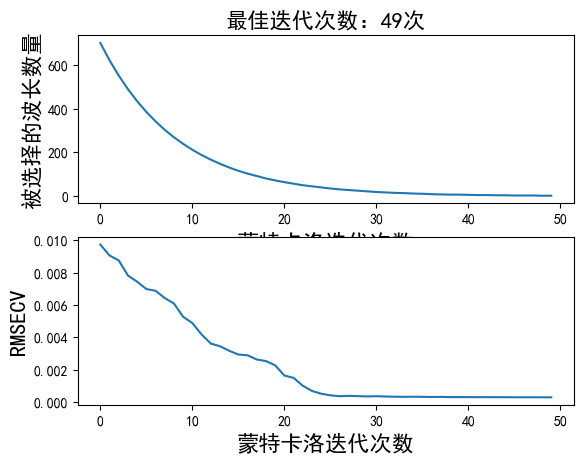

In [51]:
ow1 = CARSPLS_wzj_1.CARS_Cloud(X,y)

In [52]:
print(ow1)

[404 504]


In [53]:
import carspls_wzj

The 1th variable sampling finished.

The 2th variable sampling finished.

The 3th variable sampling finished.

The 4th variable sampling finished.

The 5th variable sampling finished.

The 6th variable sampling finished.

The 7th variable sampling finished.

The 8th variable sampling finished.

The 9th variable sampling finished.

The 10th variable sampling finished.

The 11th variable sampling finished.

The 12th variable sampling finished.

The 13th variable sampling finished.

The 14th variable sampling finished.

The 15th variable sampling finished.

The 16th variable sampling finished.

The 17th variable sampling finished.

The 18th variable sampling finished.

The 19th variable sampling finished.

The 20th variable sampling finished.

The 21th variable sampling finished.

The 22th variable sampling finished.

The 23th variable sampling finished.

The 24th variable sampling finished.

The 25th variable sampling finished.

The 26th variable sampling finished.

The 27th variable sam

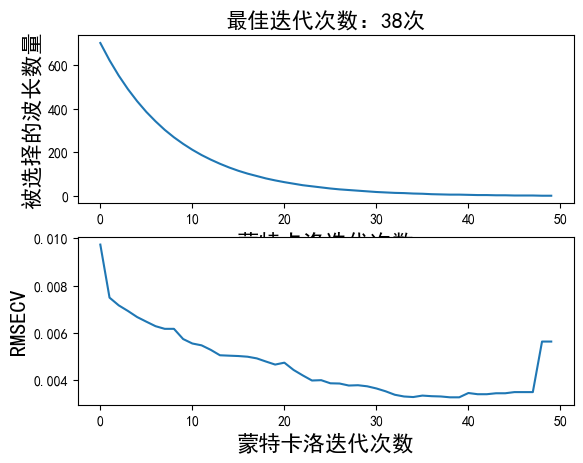

In [54]:
ow0 = carspls_wzj.CARS_Cloud(X,y)

In [55]:
print(ow0)

[403 404 503 505 507 509 511]


In [56]:
#最后使用交叉验证3个文档算法的优劣：
def PC_Cross_Validation(X, y, pc, cv):
    '''
        x :光谱矩阵 nxm
        y :浓度阵 （化学值）
        pc:最大主成分数
        cv:交叉验证数量
    return :
        RMSECV:各主成分数对应的RMSECV
        rindex:最佳主成分数
    '''
    kf = KFold(n_splits=cv)
    RMSECV = []
    
    if X.shape[1]<pc:
        pc = X.shape[1]#PLSR的主成分数不能大于X的特征数量。
    for i in range(pc):
        RMSE = []
        for train_index, test_index in kf.split(X):
            x_train, x_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            pls = PLSRegression(n_components=i + 1)
            pls.fit(x_train, y_train)
            y_predict = pls.predict(x_test)
            RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
        RMSE_mean = np.mean(RMSE)
        RMSECV.append(RMSE_mean)
    rindex = np.argmin(RMSECV)
    return RMSECV, rindex

def Cross_Validation(X, y, pc, cv):
    '''
     x :光谱矩阵 nxm
     y :浓度阵 （化学值）
     pc:最大主成分数
     cv:交叉验证数量
     return :
            RMSECV:各主成分数对应的RMSECV
    '''
    kf = KFold(n_splits=cv)
    RMSE = []
    for train_index, test_index in kf.split(X):
        x_train, x_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        pls = PLSRegression(n_components=pc)
        pls.fit(x_train, y_train)
        y_predict = pls.predict(x_test)
        RMSE.append(np.sqrt(mean_squared_error(y_test, y_predict)))
    RMSE_mean = np.mean(RMSE)
    return RMSE_mean

In [57]:
RMSECV, rindex = PC_Cross_Validation(X[:,ow0],y,20,10)
print('RMSECV:',RMSECV)
print('rindex:',rindex)
RMSE_mean = Cross_Validation(X[:,ow0],y,rindex+1,10)
print('RMSE_mean:',RMSE_mean) #等于min(RMSECV)

RMSECV: [0.29157013584566666, 0.013610238592848184, 0.008367939982393763, 0.0033906942308230526, 0.003271446611652444, 0.003306680102601968, 0.0032991208930188967]
rindex: 4
RMSE_mean: 0.003271446611652444


In [58]:
RMSECV, rindex = PC_Cross_Validation(X[:,ow1],y,20,10)
print('RMSECV:',RMSECV)
print('rindex:',rindex)
RMSE_mean = Cross_Validation(X[:,ow1],y,rindex+1,10)
print('RMSE_mean:',RMSE_mean) #等于min(RMSECV)

RMSECV: [0.29503007967049955, 0.00029093732855019005]
rindex: 1
RMSE_mean: 0.00029093732855019005


In [59]:
RMSECV, rindex = PC_Cross_Validation(X[:,ow2],y,20,10)
print('RMSECV:',RMSECV)
print('rindex:',rindex)
RMSE_mean = Cross_Validation(X[:,ow2],y,rindex+1,10)
print('RMSE_mean:',RMSE_mean) #等于min(RMSECV)

RMSECV: [0.29503007967049955, 0.00029093732855019005]
rindex: 1
RMSE_mean: 0.00029093732855019005


In [60]:
#继续深入探索carpls_wzj.py,重点考查W及WaveNum

#定义自适应重加权采样函数（Adaptive reweighted sampling）
def weightsampling_in1(w):
    #%输入参数是根据每次循环波长点保留率去除了（归零）绝对值较小的模型参数后
    #%的遗留模型参数。注意：w是取了绝对值后的模型参数向量。
    #%Bootstrap sampling
    w = w/np.sum(w) #同文献公式（3），计算w向量每一个元素所占权重
    N1 = w.shape[0] #w长度不变，但是w里面0的个数会上升
    
    min_sec = np.zeros((N1,1))
    max_sec = np.zeros((N1,1))
    min_sec[0] = 0
    max_sec[0] = w[0]
    for j in range(1,N1):
        max_sec[j] = np.sum(w[range(0,j+1)])
        min_sec[j] = np.sum(w[range(0,j)])
        #max_sec[j] - min_sec[j] = w[j]
    sel = np.zeros((N1,1))
    for i in range(0,N1):
        bb = random.random()#产生一个0~1的随机数。
        ii = 0;
        while ((min_sec[ii]>=bb or bb>max_sec[ii]) and (ii<N1)):
            ii = ii+1
        sel[i] = ii
    return sel.squeeze()

Mx = X.shape[0]#样品数量
Nx = X.shape[1]#样品波长点数量（特征数量）
f = min([Mx,Nx,f])#f不超过样品数，也不超过样品特征数
    
ratio = 0.8#建模校正集样品占比
r0=1#初始波长点保留率
r1=2/Nx
    
Vsel = np.arange(0,Nx)#初始筛选波长点位置数据，
#第一次循环取所有波长点数据，Vsel每次循环会改变数值和大小。这是一个需要重点关注的参数。
Q = int(np.floor(Mx*ratio));#建模校正集样品数量
W = np.zeros((Nx,num))#用于保存每次循环的PLSR模型的参数（每列），这是一个非常重要的参数
Ratio = []#空列表，用于保存每次循环波长点保留率。
    
WaveNum =[]#列表，用于保存下面各次循环保存的波长点数量
    
## 定义文章中的指数下降函数两个参数：
#b就是文章中的k参数（公式6）；a还是a（文章公式5）
b = np.log(r0/r1)/(num-1)
a = r0*np.exp(b)
x = copy.deepcopy(X)
#主循环：
for iter in np.arange(1,num+1):#循环50次（默认）
    Ratio.append(a*np.exp(-1*b*iter))#u*np.exp(-1*k*i):各次循环的波长点的保留率,同书P81推导
    K = int(np.round(Ratio[iter-1]*Nx))#K：每次循环保留的波长点的数量，每次循环都会变
    WaveNum = np.hstack((WaveNum, K)).astype(int)#WaveNum转为np数组，用于保存每次循环保留的波长点      #的数量
    cal_index = np.random.choice    \
        (np.arange(Mx), size=int(Q), replace=False)#从0~Mx-1中随机取Q个数，
    #且不重复
    xcal = x[np.ix_(list(cal_index),list(Vsel.astype(int)))]#按cal_index随机取样品数的光谱，
    #按Vsel取波长点数
    ycal = y[cal_index]
        
    MM = xcal.shape[0]
    NN = xcal.shape[1]
    f = min([MM,NN,f])
    pls = PLSRegression(n_components=f)#创建PLSR模型，主成分数为f,默认为8
    pls.fit(xcal,ycal)
    coef = pls.coef_#获取模型参数（1，n）反映每个波长点对y变量的相关贡献程度
    coef = coef.T#（n,1），注意n的大小每次循环会改变。
    w = np.zeros((Nx,1))#创建一个Nx*1的列向量
    w[Vsel.astype(int)] = coef#w也是一个需要重点关注的参数。
    W[:,iter-1] = w.squeeze() #将每次循环PLSR模型参数保存到W的每一列中。小w用来对模型参数进行排序
    w = np.abs(w)#对每次循环建立的PLSR模型的参数取绝对值，w全部变成正数了。
    indexw = np.argsort(-w.squeeze())##按模型参数绝对值大小，从大到小排序，indexw返回原数据在coef的
    #位置序号
    #coeff = coef[indexw];#coeff是按绝对值从大到小排序后的向量。
    KK = int(np.round(a*np.exp(-1*b*(iter+1))*Nx))
    w[indexw[KK:]]=0#只保留"波长点保留数"大小的模型参数
    #绝对值较小的模型参数归零，归零的比例为ratio
    # %+++ Eliminate some variables with small coefficients. 
    Vsel=weightsampling_in1(w);#Adaptive reweighted sampling的程序实现函数%+++ Reweighted Sampling from the pool of retained variables.                 
    Vsel= np.unique(Vsel)#用于查找并移除数组中的重复元素，并返回经过排序（从小到大）的唯一元素列表。数据量会下降            
    print('The %dth variable sampling finished.\n'%iter)    #%+++ Screen output.

The 1th variable sampling finished.

The 2th variable sampling finished.

The 3th variable sampling finished.

The 4th variable sampling finished.

The 5th variable sampling finished.

The 6th variable sampling finished.

The 7th variable sampling finished.

The 8th variable sampling finished.

The 9th variable sampling finished.

The 10th variable sampling finished.

The 11th variable sampling finished.

The 12th variable sampling finished.

The 13th variable sampling finished.

The 14th variable sampling finished.

The 15th variable sampling finished.

The 16th variable sampling finished.

The 17th variable sampling finished.

The 18th variable sampling finished.

The 19th variable sampling finished.

The 20th variable sampling finished.

The 21th variable sampling finished.

The 22th variable sampling finished.

The 23th variable sampling finished.

The 24th variable sampling finished.

The 25th variable sampling finished.

The 26th variable sampling finished.

The 27th variable sam

In [61]:
WaveNum

array([700, 621, 551, 489, 434, 385, 342, 303, 269, 239, 212, 188, 167,
       148, 131, 116, 103,  92,  81,  72,  64,  57,  50,  45,  40,  35,
        31,  28,  25,  22,  19,  17,  15,  14,  12,  11,   9,   8,   7,
         7,   6,   5,   5,   4,   4,   3,   3,   3,   2,   2])

In [62]:
W

array([[ 0.00156898,  0.00112382,  0.00369169, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.00159161,  0.0011716 ,  0.00373412, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.00160788,  0.00119304,  0.00374956, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.00316381, -0.00464672, -0.0043751 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.00315621,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.0031524 , -0.00462874, -0.0043617 , ...,  0.        ,
         0.        ,  0.        ]])

In [66]:
#记录W每一列不为0.的元素个数：
WN = []
for i in range(W.shape[1]):
    vsel = np.where(W[:,i]!=0.)
    #print(vsel)
    WN.append(vsel[0].shape[0])

In [69]:
WN

[700,
 380,
 308,
 270,
 243,
 227,
 217,
 206,
 198,
 191,
 184,
 180,
 164,
 146,
 131,
 116,
 102,
 92,
 81,
 72,
 64,
 57,
 50,
 45,
 40,
 35,
 31,
 28,
 25,
 22,
 19,
 17,
 15,
 14,
 12,
 11,
 9,
 8,
 7,
 7,
 6,
 5,
 5,
 4,
 4,
 3,
 3,
 3,
 2,
 2]

In [71]:
#很显然，经过ARS及指数下降一起去波长点数据后，波长点数据的数量下降更快。
#WN最后的数值与WaveNum最后的数值非常接近。

In [72]:
###继续对CARSPLS_wzj_w.py文档的W及WaveNum进行探索：

#定义自适应重加权采样函数（Adaptive reweighted sampling）
def weightsampling_in(w):
    #%输入参数是根据每次循环波长点保留率去除了（归零）绝对值较小的模型参数后
    #%的遗留模型参数。注意：w是取了绝对值后的模型参数向量。
    #%Bootstrap sampling
    w = w/np.sum(w) #同文献公式（3），计算w向量每一个元素所占权重
    N1 = w.shape[0]
    chosen_number = random.choices(range(0,N1),weights = w,k=N1)#符合梁文章的Fig.2
    #权重越大，波长点位置被选择的概率越大
    a = np.sort(chosen_number)#从小到大排序
    Vsel = np.unique(a)
    return Vsel #返回的Vsel就是ARS选择的波长点位置数据

Mx = X.shape[0]#样品数量
Nx = X.shape[1]#样品波长点数量（特征数量）
f = min([Mx,Nx,f])#f不超过样品数，也不超过样品特征数
    
ratio = 0.8#建模校正集样品占比
r0=1#初始波长点保留率
r1=2/Nx
    
Vsel = np.arange(0,Nx)#初始筛选波长点位置数据，
#第一次循环取所有波长点数据，Vsel每次循环会改变数值和大小。这是一个需要重点关注的参数。
Q = int(np.floor(Mx*ratio));#建模校正集样品数量
W1 = np.zeros((Nx,num))#用于保存每次循环的PLSR模型的参数（每列），这是一个非常重要的参数
Ratio = []#空列表，用于保存每次循环波长点保留率。
    
WaveNum1 =[]#列表，用于保存下面各次循环保存的波长点数量
    
## 定义文章中的指数下降函数两个参数：
#b就是文章中的k参数（公式6）；a还是a（文章公式5）
b = np.log(r0/r1)/(num-1)
a = r0*np.exp(b)
x = copy.deepcopy(X)
#主循环：
for iter in np.arange(1,num+1):#循环50次（默认）
    Ratio.append(a*np.exp(-1*b*iter))#u*np.exp(-1*k*i):各次循环的波长点的保留率,同书P81推导
    K = int(np.round(Ratio[iter-1]*Nx))#K：每次循环保留的波长点的数量，每次循环都会变
    WaveNum1 = np.hstack((WaveNum, K)).astype(int)#WaveNum转为np数组，用于保存每次循环保留的波长点      #的数量
    cal_index = np.random.choice    \
        (np.arange(Mx), size=int(Q), replace=False)#从0~Mx-1中随机取Q个数，
    #且不重复
    xcal = x[np.ix_(list(cal_index),list(Vsel.astype(int)))]#按cal_index随机取样品数的光谱，
    #按Vsel取波长点数
    ycal = y[cal_index]
        
    MM = xcal.shape[0]
    NN = xcal.shape[1]
    f = min([MM,NN,f])
    pls = PLSRegression(n_components=f)#创建PLSR模型，主成分数为f,默认为8
    pls.fit(xcal,ycal)
    coef = pls.coef_#获取模型参数（1，n）反映每个波长点对y变量的相关贡献程度
    coef = coef.T#（n,1），注意n的大小每次循环会改变。
    w = np.zeros((Nx,1))#创建一个Nx*1的列向量
    w[Vsel.astype(int)] = coef#w也是一个需要重点关注的参数。
    W1[:,iter-1] = w.squeeze() #将每次循环PLSR模型参数保存到W的每一列中。小w用来对模型参数进行排序
    w = np.abs(w)#对每次循环建立的PLSR模型的参数取绝对值，w全部变成正数了。
    indexw = np.argsort(-w.squeeze())##按模型参数绝对值大小，从大到小排序，indexw返回原数据在coef的
    #位置序号
    #coeff = coef[indexw];#coeff是按绝对值从大到小排序后的向量。
    KK = int(np.round(a*np.exp(-1*b*(iter+1))*Nx))
    w[indexw[KK:]]=0#只保留"波长点保留数"大小的模型参数
    #绝对值较小的模型参数归零，归零的比例为ratio
    # %+++ Eliminate some variables with small coefficients. 
    Vsel=weightsampling_in(w)#Adaptive reweighted sampling的程序实现函数%+++ Reweighted Sampling from the pool of retained variables.                 
    #Vsel= np.unique(Vsel)#用于查找并移除数组中的重复元素，并返回经过排序（从小到大）的唯一元素列表。数据量会下降            
    print('The %dth variable sampling finished.\n'%iter)    #%+++ Screen output.

The 1th variable sampling finished.

The 2th variable sampling finished.

The 3th variable sampling finished.

The 4th variable sampling finished.

The 5th variable sampling finished.

The 6th variable sampling finished.

The 7th variable sampling finished.

The 8th variable sampling finished.

The 9th variable sampling finished.

The 10th variable sampling finished.

The 11th variable sampling finished.

The 12th variable sampling finished.

The 13th variable sampling finished.

The 14th variable sampling finished.

The 15th variable sampling finished.

The 16th variable sampling finished.

The 17th variable sampling finished.

The 18th variable sampling finished.

The 19th variable sampling finished.

The 20th variable sampling finished.

The 21th variable sampling finished.

The 22th variable sampling finished.

The 23th variable sampling finished.

The 24th variable sampling finished.

The 25th variable sampling finished.

The 26th variable sampling finished.

The 27th variable sam

In [73]:
WaveNum1

array([700, 621, 551, 489, 434, 385, 342, 303, 269, 239, 212, 188, 167,
       148, 131, 116, 103,  92,  81,  72,  64,  57,  50,  45,  40,  35,
        31,  28,  25,  22,  19,  17,  15,  14,  12,  11,   9,   8,   7,
         7,   6,   5,   5,   4,   4,   3,   3,   3,   2,   2,   2])

In [74]:
#记录W1每一列不为0.的元素个数：
WN1 = []
for i in range(W1.shape[1]):
    vsel = np.where(W1[:,i]!=0.)
    #print(vsel)
    WN1.append(vsel[0].shape[0])
print(np.array(WN1))

[700 373 291 253 234 209 200 191 189 181 173 166 163 145 131 116 103  92
  81  72  64  57  50  45  40  35  31  28  25  22  19  17  15  14  12  11
   9   8   7   7   6   5   5   4   4   3   3   3   2   2]


In [75]:
print(np.array(WN))

[700 380 308 270 243 227 217 206 198 191 184 180 164 146 131 116 102  92
  81  72  64  57  50  45  40  35  31  28  25  22  19  17  15  14  12  11
   9   8   7   7   6   5   5   4   4   3   3   3   2   2]


In [76]:
print(np.array(WaveNum))

[700 621 551 489 434 385 342 303 269 239 212 188 167 148 131 116 103  92
  81  72  64  57  50  45  40  35  31  28  25  22  19  17  15  14  12  11
   9   8   7   7   6   5   5   4   4   3   3   3   2   2]
